<a href="https://colab.research.google.com/github/Dev5710/data555/blob/main/DATA555_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
"""Upon beginning each colab session I downloaded the source data from kagglehub according to the instructions provided at: https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data"""

import kagglehub

# Download latest version
path = kagglehub.dataset_download("harrimansaragih/dummy-advertising-and-sales-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dummy-advertising-and-sales-data' dataset.
Path to dataset files: /kaggle/input/dummy-advertising-and-sales-data


Scatterplot 1:



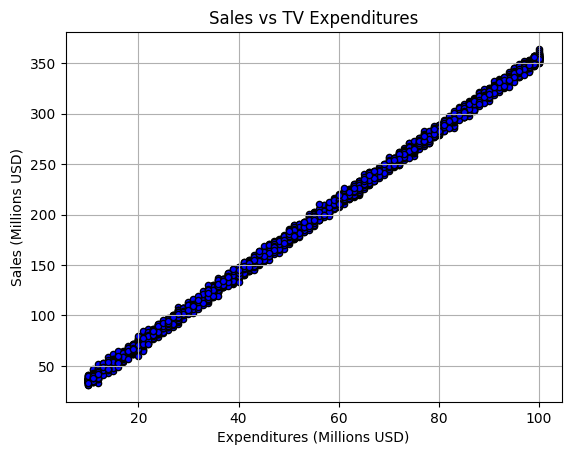


Scatterplot 2:



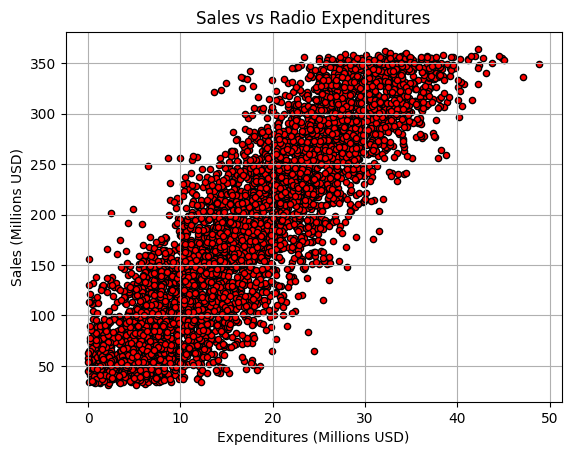


Scatterplot 3:



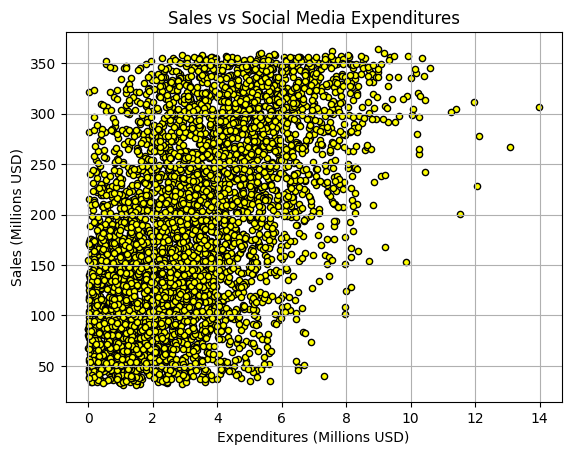


Boxplot 1:



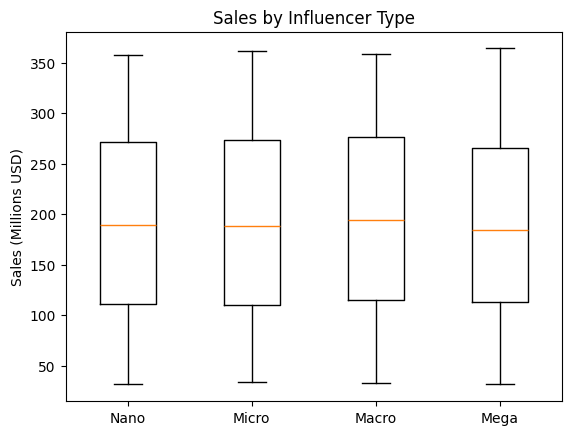

In [16]:
"""I first decided obtain scatterplots of Sales vs each of: TV, Radio, Social Media. This was done to evaluate whether a linear or non-linear relationship existed between Sales and each variable to know which regression model to use"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# I began by importing the data from the CSV file into a Pandas dataframe, then cleaned the data by removing duplicate entries, missing values, and whitespaces"""
sales_data = pd.read_csv('/kaggle/input/dummy-advertising-and-sales-data/Dummy Data HSS.csv')  # import data from CSV into pandas dataframe
sales_data = sales_data.drop_duplicates()  # drop duplicate entries
sales_data['Influencer'] = sales_data['Influencer'].str.strip()  # clean up whitespace on string values
sales_data = sales_data.dropna()  # drop missing values from dataset

# scatterplots were then created using matplotlib
sales_data.plot.scatter(x = 'TV', y = 'Sales', grid=True, color='blue', edgecolor='black')  # create scatterplot of Sales Revenues vs TV Expenditures
plt.title('Sales vs TV Expenditures')
plt.ylabel('Sales (Millions USD)')
plt.xlabel('Expenditures (Millions USD)')
print('Scatterplot 1:')
print('')
plt.show()
print('')

sales_data.plot.scatter(x = 'Radio', y = 'Sales', grid=True, color='red', edgecolor='black')  # create scatterplot of Sales Revenues vs Radio Expenditures
plt.title('Sales vs Radio Expenditures')
plt.ylabel('Sales (Millions USD)')
plt.xlabel('Expenditures (Millions USD)')
print('Scatterplot 2:')
print('')
plt.show()
print('')

sales_data.plot.scatter(x = 'Social Media', y = 'Sales', grid=True, color='yellow', edgecolor='black')  # create scatterplot of Sales Revenues vs Social Media Expenditures
plt.title('Sales vs Social Media Expenditures')
plt.ylabel('Sales (Millions USD)')
plt.xlabel('Expenditures (Millions USD)')
print('Scatterplot 3:')
print('')
plt.show()
print('')


# Boxplots were then created using code adapted from https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.boxplot.html#matplotlib.axes.Axes.boxplot
nano = sales_data.loc[sales_data['Influencer'] == 'Nano']  # isolate Nano influencer entries
micro = sales_data.loc[sales_data['Influencer'] == 'Micro']  # isolate Micro influencer entries
macro = sales_data.loc[sales_data['Influencer'] == 'Macro']  # isolate Macro influencer entries
mega = sales_data.loc[sales_data['Influencer'] == 'Mega']  # isolate Mega influencer entries
values = [np.array(nano['Sales']), np.array(micro['Sales']), np.array(macro['Sales']), np.array(mega['Sales'])]  # define categories for boxplots
plt.ylabel('Sales (Millions USD)')  # create y-axis label for boxplots
plt.boxplot(values, tick_labels = ['Nano', 'Micro', 'Macro', 'Mega']) # create boxplots
plt.title('Sales by Influencer Type')
print('Boxplot 1:')
print('')
plt.show() # display boxplots
print('')




In [ ]:
"""Note: when I tried answering this question in a text cell the formatting with the plots above was erratic and not everything was visible so I elected to write it as a comment in a code cell instead


I elected to create 3 scatterplots showing Sales Revenue (target variable) vs each of TV, Radio, and Social Media Expenditures (explanatory variables) to identify whether a linear or non-linear
relationship existed between the target or explanatory variables. I also created boxplots displaying the distribution of Sales Revenue for each type of Influencer, as if there were large
differences that would influence which type of regression should be used. Since two explanatory variables (TV and Radio) showed obvious linear relationships to Sales while Social Media did not
display an obvious non-linear relationship and no clear differences were observed between Influencer Types, I elected to use multivariate linear regression with the Least Squares method for
subsequent analysis.

"""


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.129e+06
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        15:36:37   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4541   BIC:                         2.277e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0889      0.119     -0.744   

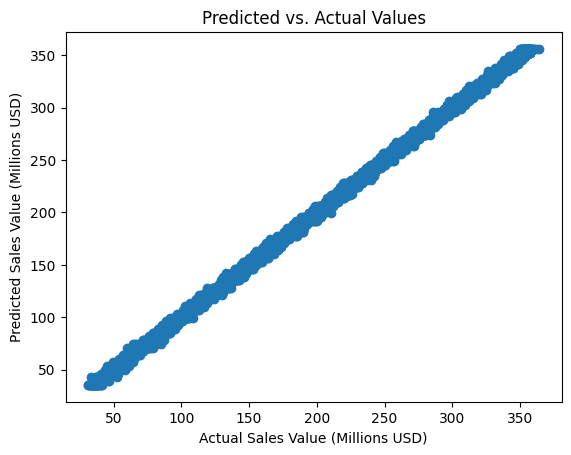

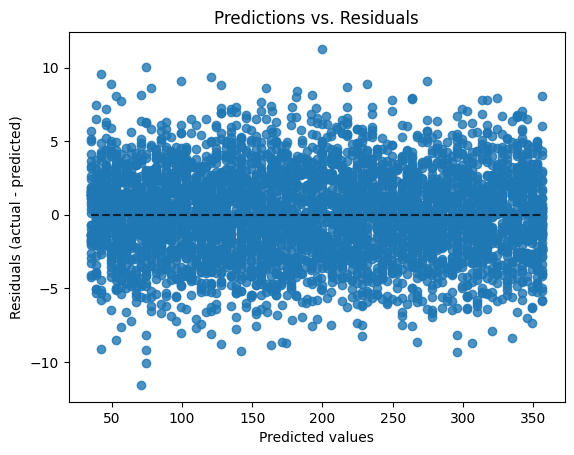

In [12]:
"""I elected to use multivariable linear regression as the only clear relationships observed between Sales Revenue and any of the 4 explanatory variables were approximately linear."""

import statsmodels.api as sm
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Data import and preprocessing was repeated as described above
sales_data = pd.read_csv('/kaggle/input/dummy-advertising-and-sales-data/Dummy Data HSS.csv')  # import data from CSV into pandas dataframe
sales_data = sales_data.drop_duplicates()  # drop duplicate entries
sales_data['Influencer'] = sales_data['Influencer'].str.strip()  # clean up whitespace on string values
sales_data = sales_data.dropna()  # drop missing values from dataset

# create/fit the linear regression model
sales_data['Influencer'] = LabelEncoder().fit_transform(sales_data['Influencer'])  # encode influencer as numerical for regression model, command adapted from: https://www.geeksforgeeks.org/machine-learning/how-to-handle-categorical-variables-in-regression/
x = sales_data[['TV', 'Radio', 'Social Media', 'Influencer']]  # define predictor variables
y = sales_data['Sales']  # define response variable
x_cons = sm.add_constant(x)  # add constant
result = sm.OLS(y, x_cons).fit()  # fit linear regression model
print(result.summary())  # display results of linear regression
y_pred = result.predict(x_cons)  # obtain predicted y-values from regression model, adapted from: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PredictionErrorDisplay.html#sklearn.metrics.PredictionErrorDisplay.from_predictions
print('')
print(f"Regression Model RMSE: {sklearn.metrics.root_mean_squared_error(y, y_pred)}")  # print MSE of regression model, adapted from: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html
print('')


# visualize the results/performance of the regression model, adapted from: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PredictionErrorDisplay.html#sklearn.metrics.PredictionErrorDisplay.from_predictions
y_pred = result.predict(x_cons)  # obtain predicted y-values from regression model, adapted from: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PredictionErrorDisplay.html#sklearn.metrics.PredictionErrorDisplay.from_predictions
plt.scatter(y, y_pred)  # plot actual vs predicted y-values
plt.xlabel('Actual Sales Value (Millions USD)')
plt.ylabel('Predicted Sales Value (Millions USD)')
plt.title('Predicted vs. Actual Values')
plt.show()
print('')
display = sklearn.metrics.PredictionErrorDisplay(y_true=y, y_pred=y_pred)  # calculate residuals from model predictions, adapted from:https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PredictionErrorDisplay.html#sklearn.metrics.PredictionErrorDisplay.from_predictions
display.plot()  # plot residuals, adapted from: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PredictionErrorDisplay.html#sklearn.metrics.PredictionErrorDisplay.from_predictions
plt.title('Predictions vs. Residuals')
plt.show()
